In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import kagglehub

## Load dataset

In [33]:
path = kagglehub.dataset_download("stephanmatzka/predictive-maintenance-dataset-ai4i-2020")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\anany\.cache\kagglehub\datasets\stephanmatzka\predictive-maintenance-dataset-ai4i-2020\versions\2


In [34]:
df = pd.read_csv(path + "/ai4i2020.csv")

## Preview of dataset

In [35]:
df.head(20)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,0,0,0,0,0
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,0,0,0,0,0
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,0,0,0,0,0
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,0,0,0,0,0
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,0,0,0,0,0


- Target column = machine failure - binary classification
- from documentation, machine failure = (TWF || HDF || PWF || OSF || RNF)

## Check for missing values

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

## Summary statistics of dataset

In [37]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


- low machine failure rate - highly imbalanced dataset
- low rates for each failure type
- low variation of temperature based features

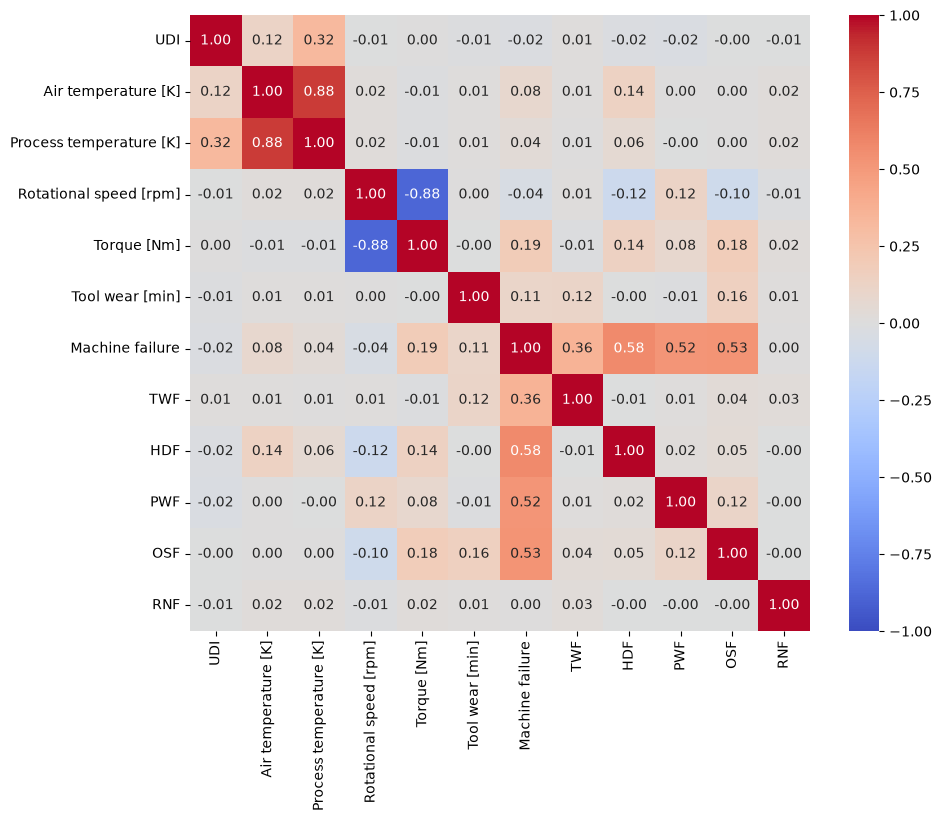

In [38]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    annot=True,      # Displays the correlation numbers inside the squares
    cmap='coolwarm',  # Visual color scale (blue = negative, red = positive)
    fmt=".2f",       # Rounds the correlation numbers to 2 decimal places
    vmin=-1,         # Sets the lower anchor for the color bar
    vmax=1           # Sets the upper anchor for the color bar
)

plt.show()


## Class-wise failure visualisation

#### Overall machine failure visualisation

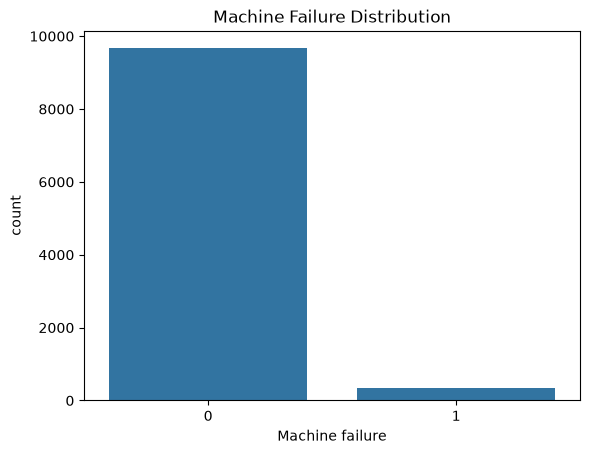

In [39]:
sns.countplot(data=df, x='Machine failure')
plt.title('Machine Failure Distribution')
plt.show()

#### Failure visualisation based on different known causes

<Figure size 640x480 with 0 Axes>

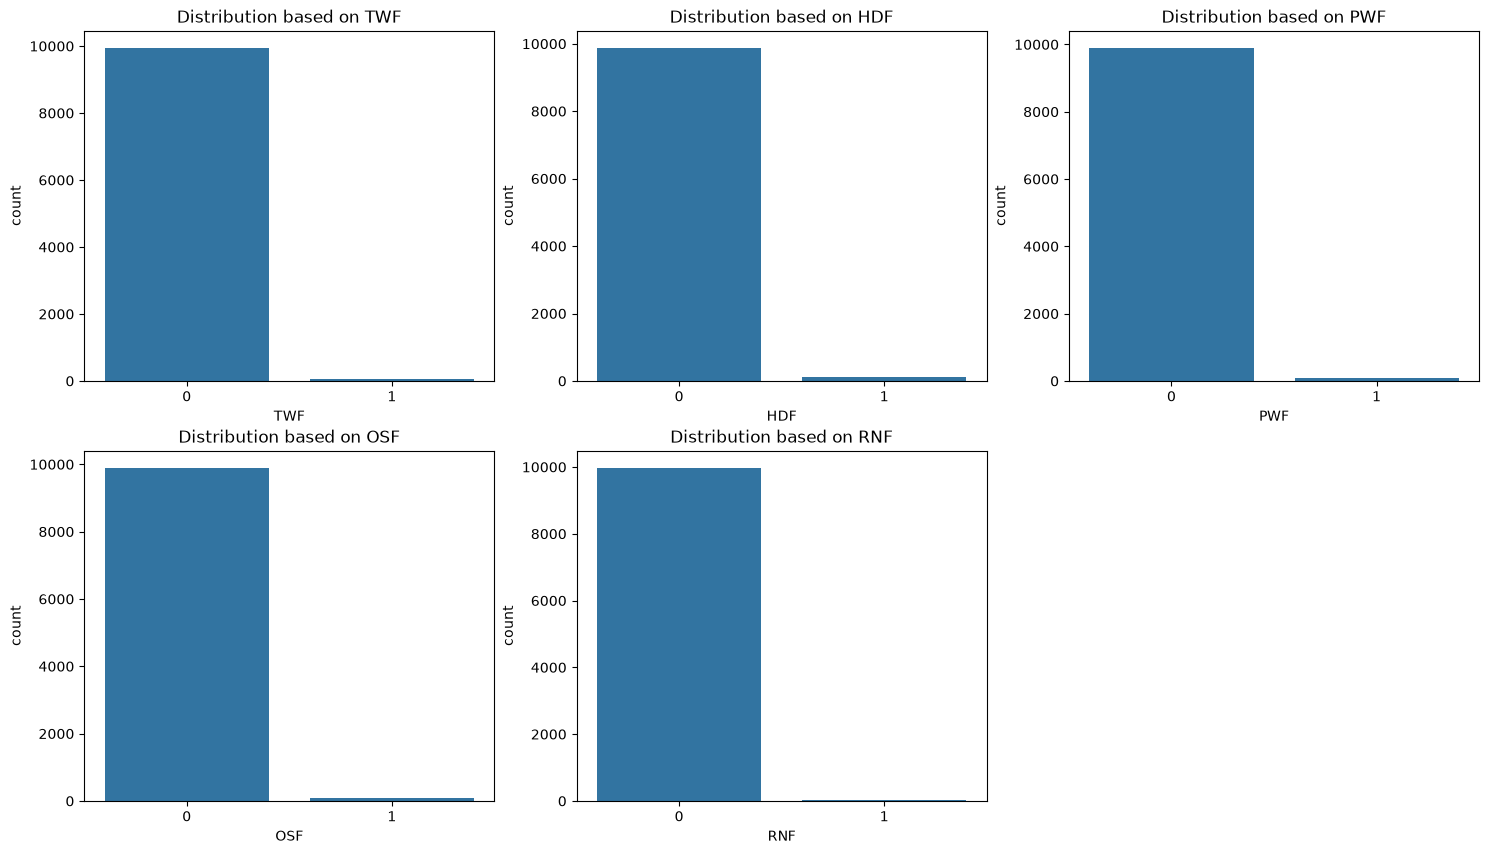

In [40]:
type_of_failures_cols = df.columns[9:]
plt.figure()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
i = 0
for type_of_failure in type_of_failures_cols:
    sns.countplot(data=df, x=type_of_failure, ax=axes[i])
    axes[i].set_title(f'Distribution based on {type_of_failure}')
    i += 1
fig.delaxes(axes.flatten()[5]) 
plt.show()


observation: severe imbalance in classes of machine failure (0 - no failure 1 - failure)

#### Failure Visualisation based on Product Quality Types

Text(0.5, 1.0, 'Machine Failure Distribution by Product Quality Type')

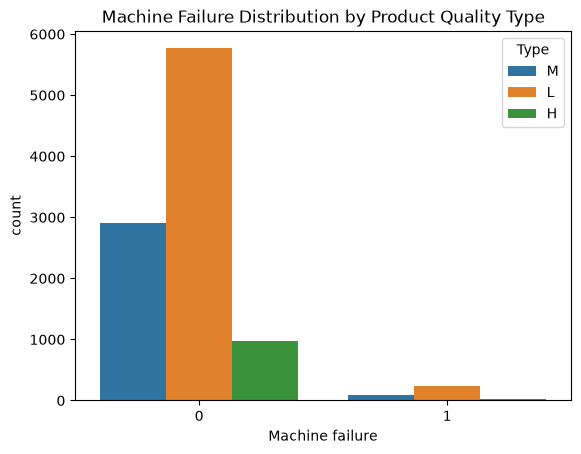

In [41]:
sns.countplot(data=df, x='Machine failure', hue='Type')
plt.title('Machine Failure Distribution by Product Quality Type')

In [42]:
# Count failures by product type
failures_by_type = df[df['Machine failure'] == 1].groupby('Type').size()
print("Failures by Product Type:")
print(failures_by_type)


Failures by Product Type:
Type
H     21
L    235
M     83
dtype: int64


In [43]:
print("\nDetailed breakdown:")
breakdown = df.groupby(['Type', 'Machine failure']).size().unstack(fill_value=0)
print(breakdown)


Detailed breakdown:
Machine failure     0    1
Type                      
H                 982   21
L                5765  235
M                2914   83


<Axes: title={'center': 'Machine Failure Rate by Product Type'}, xlabel='Type'>

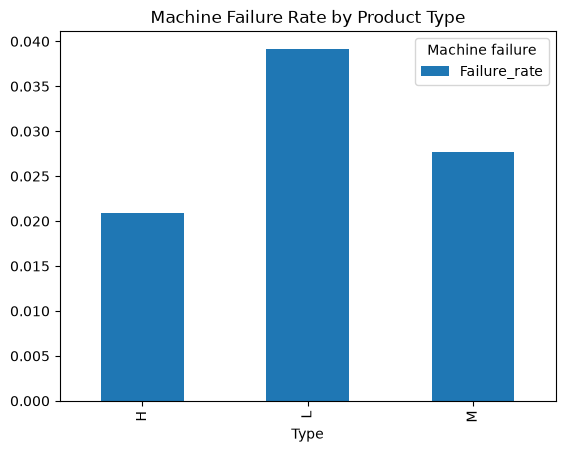

In [44]:
breakdown['Failure_rate'] = breakdown[1] / (breakdown[0] + breakdown[1])
breakdown[['Failure_rate']].plot(kind='bar', title='Machine Failure Rate by Product Type')

Observation: machine rate failures seem to be lower when manufacturing higher quality products

<Figure size 640x480 with 0 Axes>

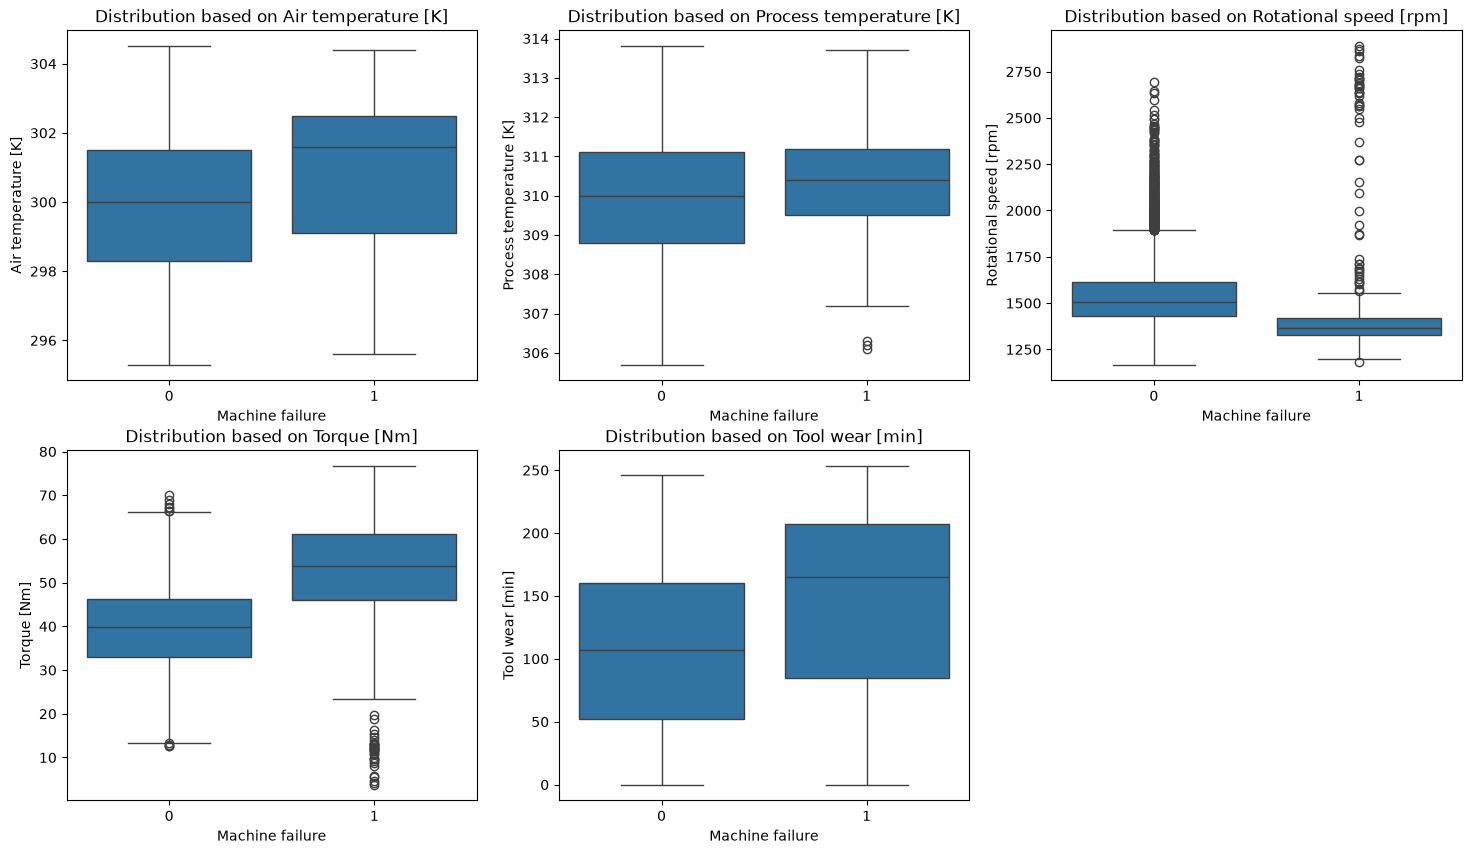

In [45]:
sensor_columns = df.columns[3:8]
plt.figure()

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration
i = 0

for sensor in sensor_columns:
    sns.boxplot(data=df, x='Machine failure', y=sensor, ax=axes[i])
    axes[i].set_title(f'Distribution based on {sensor}')
    i += 1
fig.delaxes(axes.flatten()[5]) 
plt.show()


- minimal overlap: rotational speed, torque
- higher torque - greater force exerted by machine - higher risk of failure
- lower rpm - higher risk of failure - (phenomenon - lugging)
- higher tool wear is associated with higher risk of failure

features showing mechanical stress are stronger predictors than temparature-based features

order of preference:
1. rpm
2. torque
3. tool wear
4. air temperature
5. process temperature (might skip entirely)

Since air temperature and process temperature were recorded, it means that they do somehow contribute to machine failure. Since the above boxplots show that they cannot do so individually, (process - air) temperature is being evaluated as a feature

In [46]:
df['Temp_difference'] = df['Process temperature [K]'] - df['Air temperature [K]']
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temp_difference
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5


Text(0.5, 1.0, 'Temperature Difference Distribution by Machine Failure')

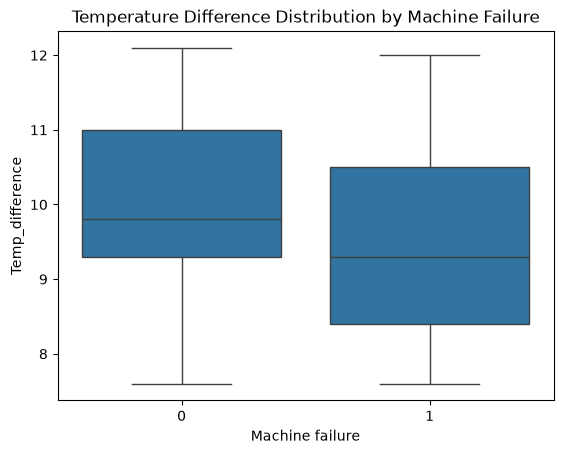

In [47]:
sns.boxplot(data=df, x='Machine failure', y='Temp_difference')
plt.title(f'Temperature Difference Distribution by Machine Failure')

- lower temperature differences seems to be associated with higher risk of failures
-  associated phenomenon that support this finding - heat trapping that causes overheating, thermal fatigue - need to investigate further

Since torque and RPM seem to individually classify machine failure clearly, (torque/rpm) is being evaluated as a predictor below

In [48]:
df['torque-per-rpm'] = df['Torque [Nm]'] / df['Rotational speed [rpm]']

Text(0.5, 1.0, 'torque-per-rpm Distribution by Machine Failure')

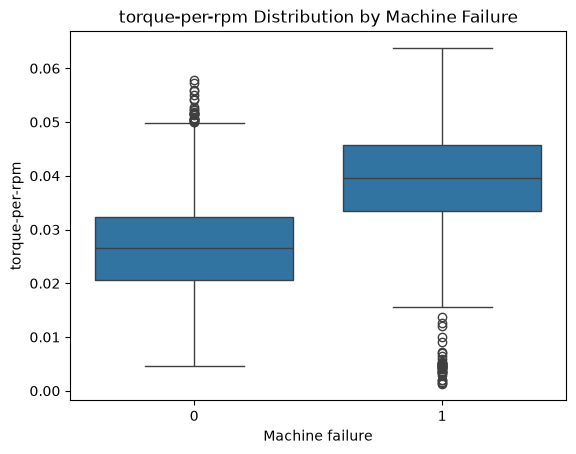

In [49]:
sns.boxplot(data=df, x='Machine failure', y='torque-per-rpm')
plt.title(f'torque-per-rpm Distribution by Machine Failure')

- greater torque to rpm ration seems to cause greater risk of machine failure
- associated phenomenon that support this finding - centrifugal stress, gyroscopic precession - exact causes cannot be predicted as of now

known fact: old machine (more tool wear) can fail under high load(torque),testing the following hypothesis below

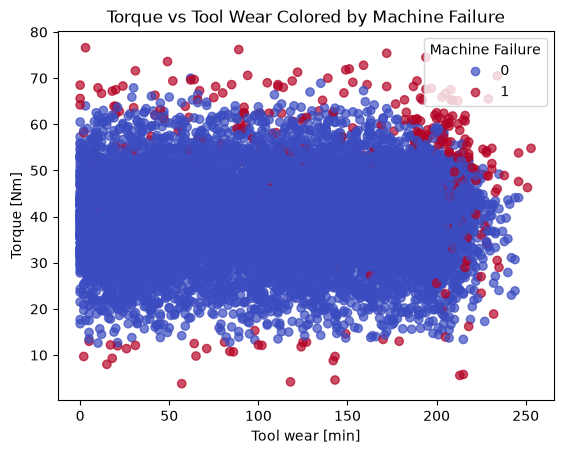

In [50]:
scatter = plt.scatter(x = df['Tool wear [min]'], y = df['Torque [Nm]'], c=df['Machine failure'], cmap='coolwarm', alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Machine Failure")
plt.xlabel('Tool wear [min]')
plt.ylabel('Torque [Nm]')
plt.title('Torque vs Tool Wear Colored by Machine Failure') 
plt.show()

Observation: torque and tool wear together do not provide much information in this dataset

assessing impact of tool wear, since tool wear failure can be observed only when enough wear has occurred

Text(0.5, 1.0, 'Distribution of Tool Wear by Machine Failure')

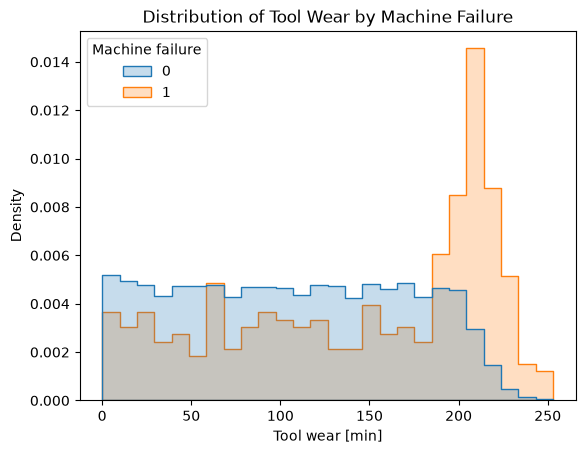

In [51]:
sns.histplot(data=df, x='Tool wear [min]', hue='Machine failure', element='step', stat='density', common_norm=False)
plt.title('Distribution of Tool Wear by Machine Failure')

increase in tool wear seems to cause increase in machine failure after a given threshold value

In [52]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Temp_difference', 'torque-per-rpm'],
      dtype='str')

#### Preprocessing for basic modelling

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix,classification_report

In [54]:
X = df.drop(columns=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'UDI', 'Temp_difference', 'torque-per-rpm', 'Product ID'])
y = df['Machine failure']

One hot encoding for Type column

In [55]:
categorical_columns = X.select_dtypes(include=['object', 'string']).columns
categorical_columns


Index(['Type'], dtype='str')

In [56]:
encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(X[categorical_columns])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_columns)
)

encoded_df.head()

,Type_H,Type_L,Type_M
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0


In [57]:
X = pd.concat(
    [X.drop(columns=categorical_columns), encoded_df],
    axis=1
)

print("\nOne-Hot Encoded Data:")
print(X.head())


One-Hot Encoded Data:
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0                298.1                    308.6                    1551   
1                298.2                    308.7                    1408   
2                298.1                    308.5                    1498   
3                298.2                    308.6                    1433   
4                298.2                    308.7                    1408   

   Torque [Nm]  Tool wear [min]  Type_H  Type_L  Type_M  
0         42.8                0     0.0     0.0     1.0  
1         46.3                3     0.0     1.0     0.0  
2         49.4                5     0.0     1.0     0.0  
3         39.5                7     0.0     1.0     0.0  
4         40.0                9     0.0     1.0     0.0  


Logistic Regression - baseline model

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.20,
                                                    random_state=23, 
                                                    stratify=y)

In [59]:
clf_baseline = LogisticRegression(class_weight='balanced', max_iter=10000, random_state=0)
clf_baseline.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",0
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [60]:
acc = accuracy_score(y_test, clf_baseline.predict(X_test)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")

Logistic Regression model accuracy: 82.35%


In [63]:
y_pred = clf_baseline.predict(X_test)

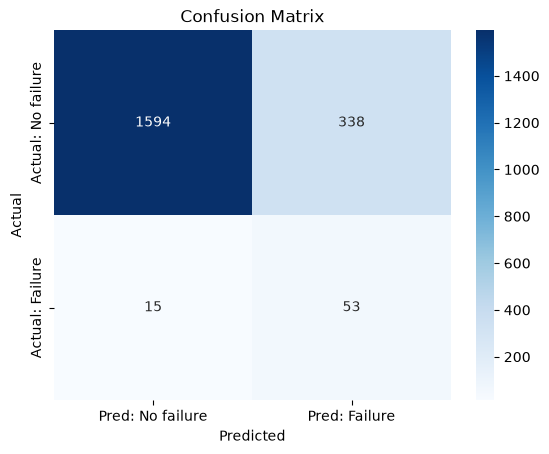

In [64]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred: No failure', 'Pred: Failure'],
    yticklabels=['Actual: No failure', 'Actual: Failure']
)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [65]:
print(classification_report(y_test, y_pred, target_names=['No failure', 'Failure']))

              precision    recall  f1-score   support

  No failure       0.99      0.83      0.90      1932
     Failure       0.14      0.78      0.23        68

    accuracy                           0.82      2000
   macro avg       0.56      0.80      0.57      2000
weighted avg       0.96      0.82      0.88      2000



Logistic Regression - all engineered features

In [66]:
X = df.drop(columns=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'UDI', 'Product ID'])
y = df['Machine failure']

In [67]:
categorical_columns = X.select_dtypes(include=['object', 'string']).columns

encoder = OneHotEncoder(sparse_output=False)
encoded_data = encoder.fit_transform(X[categorical_columns])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_columns)
)

encoded_df.head()

,Type_H,Type_L,Type_M
0,0.0,0.0,1.0
1,0.0,1.0,0.0
2,0.0,1.0,0.0
3,0.0,1.0,0.0
4,0.0,1.0,0.0


In [68]:
X = pd.concat(
    [X.drop(columns=categorical_columns), encoded_df],
    axis=1
)

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.20,
                                                    random_state=23, 
                                                    stratify=y)

In [70]:
clf_torque = LogisticRegression(class_weight='balanced', max_iter=10000, random_state=0)
clf_torque.fit(X_train, y_train)
acc = accuracy_score(y_test, clf_torque.predict(X_test)) * 100
print(f"Logistic Regression model accuracy: {acc:.2f}%")

Logistic Regression model accuracy: 82.45%


In [71]:
y_pred = clf_torque.predict(X_test)

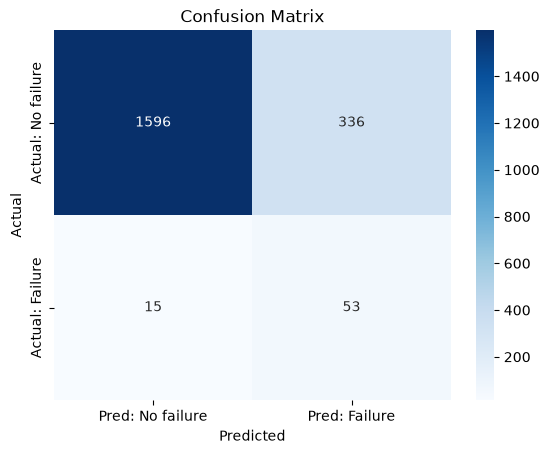

In [72]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred: No failure', 'Pred: Failure'],
    yticklabels=['Actual: No failure', 'Actual: Failure']
)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [73]:
print(classification_report(y_test, y_pred, target_names=['No failure', 'Failure']))

              precision    recall  f1-score   support

  No failure       0.99      0.83      0.90      1932
     Failure       0.14      0.78      0.23        68

    accuracy                           0.82      2000
   macro avg       0.56      0.80      0.57      2000
weighted avg       0.96      0.82      0.88      2000



Engineered features have negligible impact on performance metrics. Moving on to investigate non-linear relationships using Random Forest

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [85]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

In [86]:
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred, target_names=['No failure', 'Failure'])

print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report Random Forest:\n", classification_rep)

Accuracy: 0.98

Classification Report Random Forest:
               precision    recall  f1-score   support

  No failure       0.99      0.99      0.99      1939
     Failure       0.75      0.67      0.71        61

    accuracy                           0.98      2000
   macro avg       0.87      0.83      0.85      2000
weighted avg       0.98      0.98      0.98      2000



- No failure class - 99% precision - 99/100 machines predicted as healthy, were healthy
- No failure class - 99% recall - 99/100 machines were correctly identified as healthy
- Failure class - 0.75 precision - 75/100 machines predicted to fail, actually failed - roughly 1 out every 4 failures was a false positive
- Failure class - 0.67 recall - 67/100 machines were correctly predicted to have failed - roughly 1 out every 3 failures was missed(false negative)
- Failure class - F1 score of 0.71 - reasonable balance between actual failures and false alarms


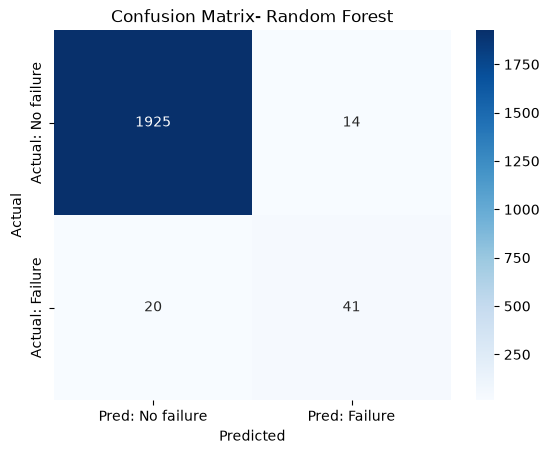

In [87]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred: No failure', 'Pred: Failure'],
    yticklabels=['Actual: No failure', 'Actual: Failure']
)
plt.title('Confusion Matrix- Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()